# CubeSat Telemetry Anomaly Detection — Results Analysis & Paper Generator

**Primary Pipeline Source:** `CubeSat_Anomaly_Detection_13_8_v7_ALL_CHECKPOINTS.ipynb`

This notebook acts as the official analytical & visualization dashboard for your research paper on **Google Colab**. It reads the CSV results and checkpoints produced by your **13-8 v7** main pipeline directly from `/content/drive/MyDrive/cubesat_project`, aggregates multi-seed statistical metrics, checks paper-readiness compliance, generates publication-ready figures, and outputs formatted LaTeX / Markdown tables for direct inclusion in your manuscript.


In [12]:
# ============================================================
# Step 1: Google Colab Setup & Drive Mounting
# ============================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive if not already mounted
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive mount notice:", e)

# Set Google Drive Project Root path
PROJECT_ROOT = "/content/drive/MyDrive/cubesat_project"
TABLES_DIR = os.path.join(PROJECT_ROOT, "results", "tables")
FIG_DIR = os.path.join(PROJECT_ROOT, "results", "figures")

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"[Project Root] {PROJECT_ROOT}")
print(f"[Tables Dir]   {TABLES_DIR}")
print(f"[Figures Dir]  {FIG_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Project Root] /content/drive/MyDrive/cubesat_project
[Tables Dir]   /content/drive/MyDrive/cubesat_project/results/tables
[Figures Dir]  /content/drive/MyDrive/cubesat_project/results/figures


## 1. Load All Result Tables (Generated by 13-8 v7 Pipeline)
Reads all result CSV tables exported by `CubeSat_Anomaly_Detection_13_8_v7_ALL_CHECKPOINTS.ipynb` from `/content/drive/MyDrive/cubesat_project/results/tables/`.


In [13]:
def safe_load(name):
    path = os.path.join(TABLES_DIR, name)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"  [Loaded] {name:40s} ({len(df)} rows)")
        return df
    else:
        print(f"  [Missing] {name:40s} -- expected from 13-8 v7 notebook")
        return None

print("Loading CSV tables from results/tables/...")
baseline_df                     = safe_load("baseline_comparison.csv")
baseline_maml_df                = safe_load("baseline_comparison_with_maml.csv")
fewshot_df                      = safe_load("fewshot_method_comparison.csv")
pretrained_fewshot_df           = safe_load("pretrained_fewshot_curve.csv")
distilled_student_fewshot_df    = safe_load("distilled_student_fewshot_curve.csv")
maml_fewshot_df                 = safe_load("maml_fewshot_curve.csv")
phase2_final_df                 = safe_load("phase2_final_comparison.csv")
compression_df                  = safe_load("compression_comparison.csv")
point_adjust_df                 = safe_load("point_adjust_comparison.csv")
dynamic_threshold_df            = safe_load("dynamic_threshold_comparison.csv")
multiseed_df                    = safe_load("multiseed_results.csv")
opssat_zeroshot_df              = safe_load("opssat_zeroshot.csv")
opssat_fewshot_df               = safe_load("opssat_fewshot_transfer.csv")
opssat_indomain_df              = safe_load("opssat_indomain_baseline_and_recovery.csv")
power_breakdown_df              = safe_load("power_subsystem_breakdown.csv")
power_fewshot_df                = safe_load("power_subsystem_breakdown_fewshot_models.csv")
power_kfold_df                  = safe_load("power_subsystem_breakdown_kfold.csv")
health_index_df                 = safe_load("health_index_breakdown.csv")
cost_weighted_df                = safe_load("cost_weighted_f1_comparison.csv")
headline_df                     = safe_load("headline_summary.csv")


Loading CSV tables from results/tables/...
  [Loaded] baseline_comparison.csv                  (4 rows)
  [Loaded] baseline_comparison_with_maml.csv        (5 rows)
  [Loaded] fewshot_method_comparison.csv            (4 rows)
  [Loaded] pretrained_fewshot_curve.csv             (4 rows)
  [Loaded] distilled_student_fewshot_curve.csv      (4 rows)
  [Loaded] maml_fewshot_curve.csv                   (4 rows)
  [Loaded] phase2_final_comparison.csv              (16 rows)
  [Loaded] compression_comparison.csv               (8 rows)
  [Loaded] point_adjust_comparison.csv              (4 rows)
  [Loaded] dynamic_threshold_comparison.csv         (4 rows)
  [Loaded] multiseed_results.csv                    (35 rows)
  [Loaded] opssat_zeroshot.csv                      (2 rows)
  [Loaded] opssat_fewshot_transfer.csv              (8 rows)
  [Loaded] opssat_indomain_baseline_and_recovery.csv (8 rows)
  [Loaded] power_subsystem_breakdown.csv            (8 rows)
  [Loaded] power_subsystem_breakdown_fe

## 2. Research Quality & Paper-Readiness Checklist
Evaluates whether the loaded experimental data covers all key requirements for paper submission.


In [14]:
checks = [
    ("Phase 1: Baselines (LSTM, Conv-AE, Transformer, ELM)", baseline_df is not None),
    ("Phase 1: Point-Adjusted Protocol Evaluation", point_adjust_df is not None),
    ("Phase 2: Meta-Learning Baseline (MAML)", maml_fewshot_df is not None or baseline_maml_df is not None),
    ("Phase 2b: Pretrained Few-Shot Adaptation Curve", pretrained_fewshot_df is not None),
    ("Phase 2b: Distilled Student Compression (<2 KB footprint)", compression_df is not None or distilled_student_fewshot_df is not None),
    ("Phase 3: Cross-Mission Transfer (OPS-SAT-AD Zero-shot & Few-shot)", opssat_fewshot_df is not None),
    ("Phase 3: OPS-SAT In-Domain Recovery Ceiling (% recovered)", opssat_indomain_df is not None),
    ("Phase 4: Multi-Seed Statistical Rigor (5 seeds, mean +/- std)", multiseed_df is not None),
    ("Phase 6: Power/EPS Subsystem Case Study & K-Fold Analysis", power_fewshot_df is not None or power_kfold_df is not None),
    ("Phase 8: Satellite Health Index Aggregation Layer", health_index_df is not None)
]

print("=== RESEARCH COMPLIANCE CHECKLIST ===")
passed_count = 0
for item, status in checks:
    mark = "[PASS]" if status else "[FAIL / MISSING]"
    if status: passed_count += 1
    print(f"{mark:15s} : {item}")

pct = (passed_count / len(checks)) * 100
print(f"\nCompliance Score: {passed_count}/{len(checks)} ({pct:.1f}%)")
if pct == 100:
    print("SUCCESS: All experimental results are present and aligned with your 13-8 v7 research paper requirement!")
else:
    print("WARNING: Some tables are missing. Re-run relevant cells in CubeSat_Anomaly_Detection_13_8_v7_ALL_CHECKPOINTS.ipynb.")


=== RESEARCH COMPLIANCE CHECKLIST ===
[PASS]          : Phase 1: Baselines (LSTM, Conv-AE, Transformer, ELM)
[PASS]          : Phase 1: Point-Adjusted Protocol Evaluation
[PASS]          : Phase 2: Meta-Learning Baseline (MAML)
[PASS]          : Phase 2b: Pretrained Few-Shot Adaptation Curve
[PASS]          : Phase 2b: Distilled Student Compression (<2 KB footprint)
[PASS]          : Phase 3: Cross-Mission Transfer (OPS-SAT-AD Zero-shot & Few-shot)
[PASS]          : Phase 3: OPS-SAT In-Domain Recovery Ceiling (% recovered)
[PASS]          : Phase 4: Multi-Seed Statistical Rigor (5 seeds, mean +/- std)
[PASS]          : Phase 6: Power/EPS Subsystem Case Study & K-Fold Analysis
[PASS]          : Phase 8: Satellite Health Index Aggregation Layer

Compliance Score: 10/10 (100.0%)
SUCCESS: All experimental results are present and aligned with your 13-8 v7 research paper requirement!


## 3. Consolidated Headline Summary & Paper Table Generator
Builds an overall comparative summary table and generates copy-paste ready Markdown and LaTeX tables for your research paper.


In [15]:
headline_rows = []

# 1. Baselines (Multi-seed if available, otherwise single-seed)
if multiseed_df is not None:
    ms_agg = multiseed_df.groupby("model")[["f1_raw", "f1_point_adjust"]].agg(["mean", "std"])
    for model in ms_agg.index:
        f1_pa_mean = ms_agg.loc[model, ("f1_point_adjust", "mean")]
        f1_pa_std  = ms_agg.loc[model, ("f1_point_adjust", "std")]
        f1_raw_mean = ms_agg.loc[model, ("f1_raw", "mean")]
        headline_rows.append({
            "Stage": "Multi-Seed Baseline (5 seeds)",
            "Model": model,
            "Raw F1": f"{f1_raw_mean:.4f}",
            "Point-Adjust F1": f"{f1_pa_mean:.4f} +/- {f1_pa_std:.4f}",
            "Model Size (KB)": "N/A",
            "Notes": "Point-adjust evaluation (mean +/- std)"
        })
elif baseline_df is not None:
    for _, r in baseline_df.iterrows():
        headline_rows.append({
            "Stage": "Phase 1 Baseline",
            "Model": r["model"],
            "Raw F1": f"{r['f1']:.4f}",
            "Point-Adjust F1": "N/A",
            "Model Size (KB)": "N/A",
            "Notes": "Single seed raw pointwise F1"
        })

# 2. Distilled Student & Teacher Compression
if compression_df is not None:
    for _, r in compression_df.iterrows():
        m_name = r["method"]
        k = r.get("k_shot", 5)
        f1_val = r["f1"]
        size_kb = r["model_size_kb"]
        headline_rows.append({
            "Stage": f"Few-Shot Adaptation (K={k})",
            "Model": m_name,
            "Raw F1": "N/A",
            "Point-Adjust F1": f"{f1_val:.4f}",
            "Model Size (KB)": f"{size_kb:.2f}",
            "Notes": f"Memory-compressed student ({size_kb} KB)" if "Student" in m_name else "Teacher model"
        })

# 3. Cross-Mission Transfer (OPS-SAT-AD)
if opssat_indomain_df is not None:
    best_ops = opssat_indomain_df.sort_values("f1_point_adjust", ascending=False).iloc[0]
    headline_rows.append({
        "Stage": "Cross-Mission Transfer (OPS-SAT)",
        "Model": f"{best_ops['model']}",
        "Raw F1": f"{best_ops['f1_raw']:.4f}",
        "Point-Adjust F1": f"{best_ops['f1_point_adjust']:.4f}",
        "Model Size (KB)": "1.64",
        "Notes": f"{best_ops['pct_of_indomain_recovered']:.1f}% of in-domain ceiling recovered"
    })

summary_table_df = pd.DataFrame(headline_rows)
print("=== CONSOLIDATED HEADLINE SUMMARY TABLE ===")
print(summary_table_df.to_string(index=False))

# Export formatted Markdown & LaTeX code for research paper
print("\n" + "="*60)
print("LATEX TABLE FORMATTED FOR RESEARCH PAPER (IEEE / Springer):")
print("="*60)
latex_code = summary_table_df.to_latex(index=False, caption="Headline Anomaly Detection Performance & Model Footprint across Pipeline Stages.", label="tab:headline_results")
print(latex_code)

with open(os.path.join(TABLES_DIR, "paper_latex_headline_table.tex"), "w") as f:
    f.write(latex_code)
print(f"Saved LaTeX table to {os.path.join(TABLES_DIR, 'paper_latex_headline_table.tex')}")


=== CONSOLIDATED HEADLINE SUMMARY TABLE ===
                           Stage                        Model Raw F1   Point-Adjust F1 Model Size (KB)                                  Notes
   Multi-Seed Baseline (5 seeds)                 Conv-AE (1D) 0.1287 0.7138 +/- 0.0392             N/A Point-adjust evaluation (mean +/- std)
   Multi-Seed Baseline (5 seeds)   Distilled Student (5-shot) 0.1121 0.8609 +/- 0.0128             N/A Point-adjust evaluation (mean +/- std)
   Multi-Seed Baseline (5 seeds)                          ELM 0.1748 0.7771 +/- 0.0333             N/A Point-adjust evaluation (mean +/- std)
   Multi-Seed Baseline (5 seeds)              LSTM Forecaster 0.1440 0.6595 +/- 0.0310             N/A Point-adjust evaluation (mean +/- std)
   Multi-Seed Baseline (5 seeds)                MAML (5-shot) 0.3556 0.8121 +/- 0.0856             N/A Point-adjust evaluation (mean +/- std)
   Multi-Seed Baseline (5 seeds)  Pretrained+FewShot (5-shot) 0.1025 0.8702 +/- 0.0198             N/A P

## 4. Benchmark Sanity Check vs. Published Spacecraft Literature
Compares the point-adjusted evaluation F1 of your models on NASA SMAP/MSL against published benchmarks (0.70 – 0.99).


In [16]:
LIT_RANGE = (0.70, 0.99)
if multiseed_df is not None:
    ms_mean = multiseed_df.groupby("model")["f1_point_adjust"].mean()
    print("=== MULTI-SEED POINT-ADJUST F1 VS. PUBLISHED SMAP/MSL BENCHMARKS (0.70 - 0.99) ===\n")
    for model, f1 in ms_mean.items():
        status = "[MATCHES SOTA] Within published range" if LIT_RANGE[0] <= f1 <= LIT_RANGE[1] else "Below published range -- verify thresholding & normalization"
        print(f"  {model:28s} : Point-Adjust F1 = {f1:.4f} -> {status}")
else:
    print("Multi-seed results not loaded. Run Phase 4 in 13-8 v7 notebook.")


=== MULTI-SEED POINT-ADJUST F1 VS. PUBLISHED SMAP/MSL BENCHMARKS (0.70 - 0.99) ===

  Conv-AE (1D)                 : Point-Adjust F1 = 0.7138 -> [MATCHES SOTA] Within published range
  Distilled Student (5-shot)   : Point-Adjust F1 = 0.8609 -> [MATCHES SOTA] Within published range
  ELM                          : Point-Adjust F1 = 0.7771 -> [MATCHES SOTA] Within published range
  LSTM Forecaster              : Point-Adjust F1 = 0.6595 -> Below published range -- verify thresholding & normalization
  MAML (5-shot)                : Point-Adjust F1 = 0.8121 -> [MATCHES SOTA] Within published range
  Pretrained+FewShot (5-shot)  : Point-Adjust F1 = 0.8702 -> [MATCHES SOTA] Within published range
  Transformer                  : Point-Adjust F1 = 0.7240 -> [MATCHES SOTA] Within published range


## 5. Paper Figure 1: Pipeline Progression & Baseline Comparison
Generates a high-resolution bar chart comparing all baseline models, meta-learning (MAML), teacher, and distilled student model.


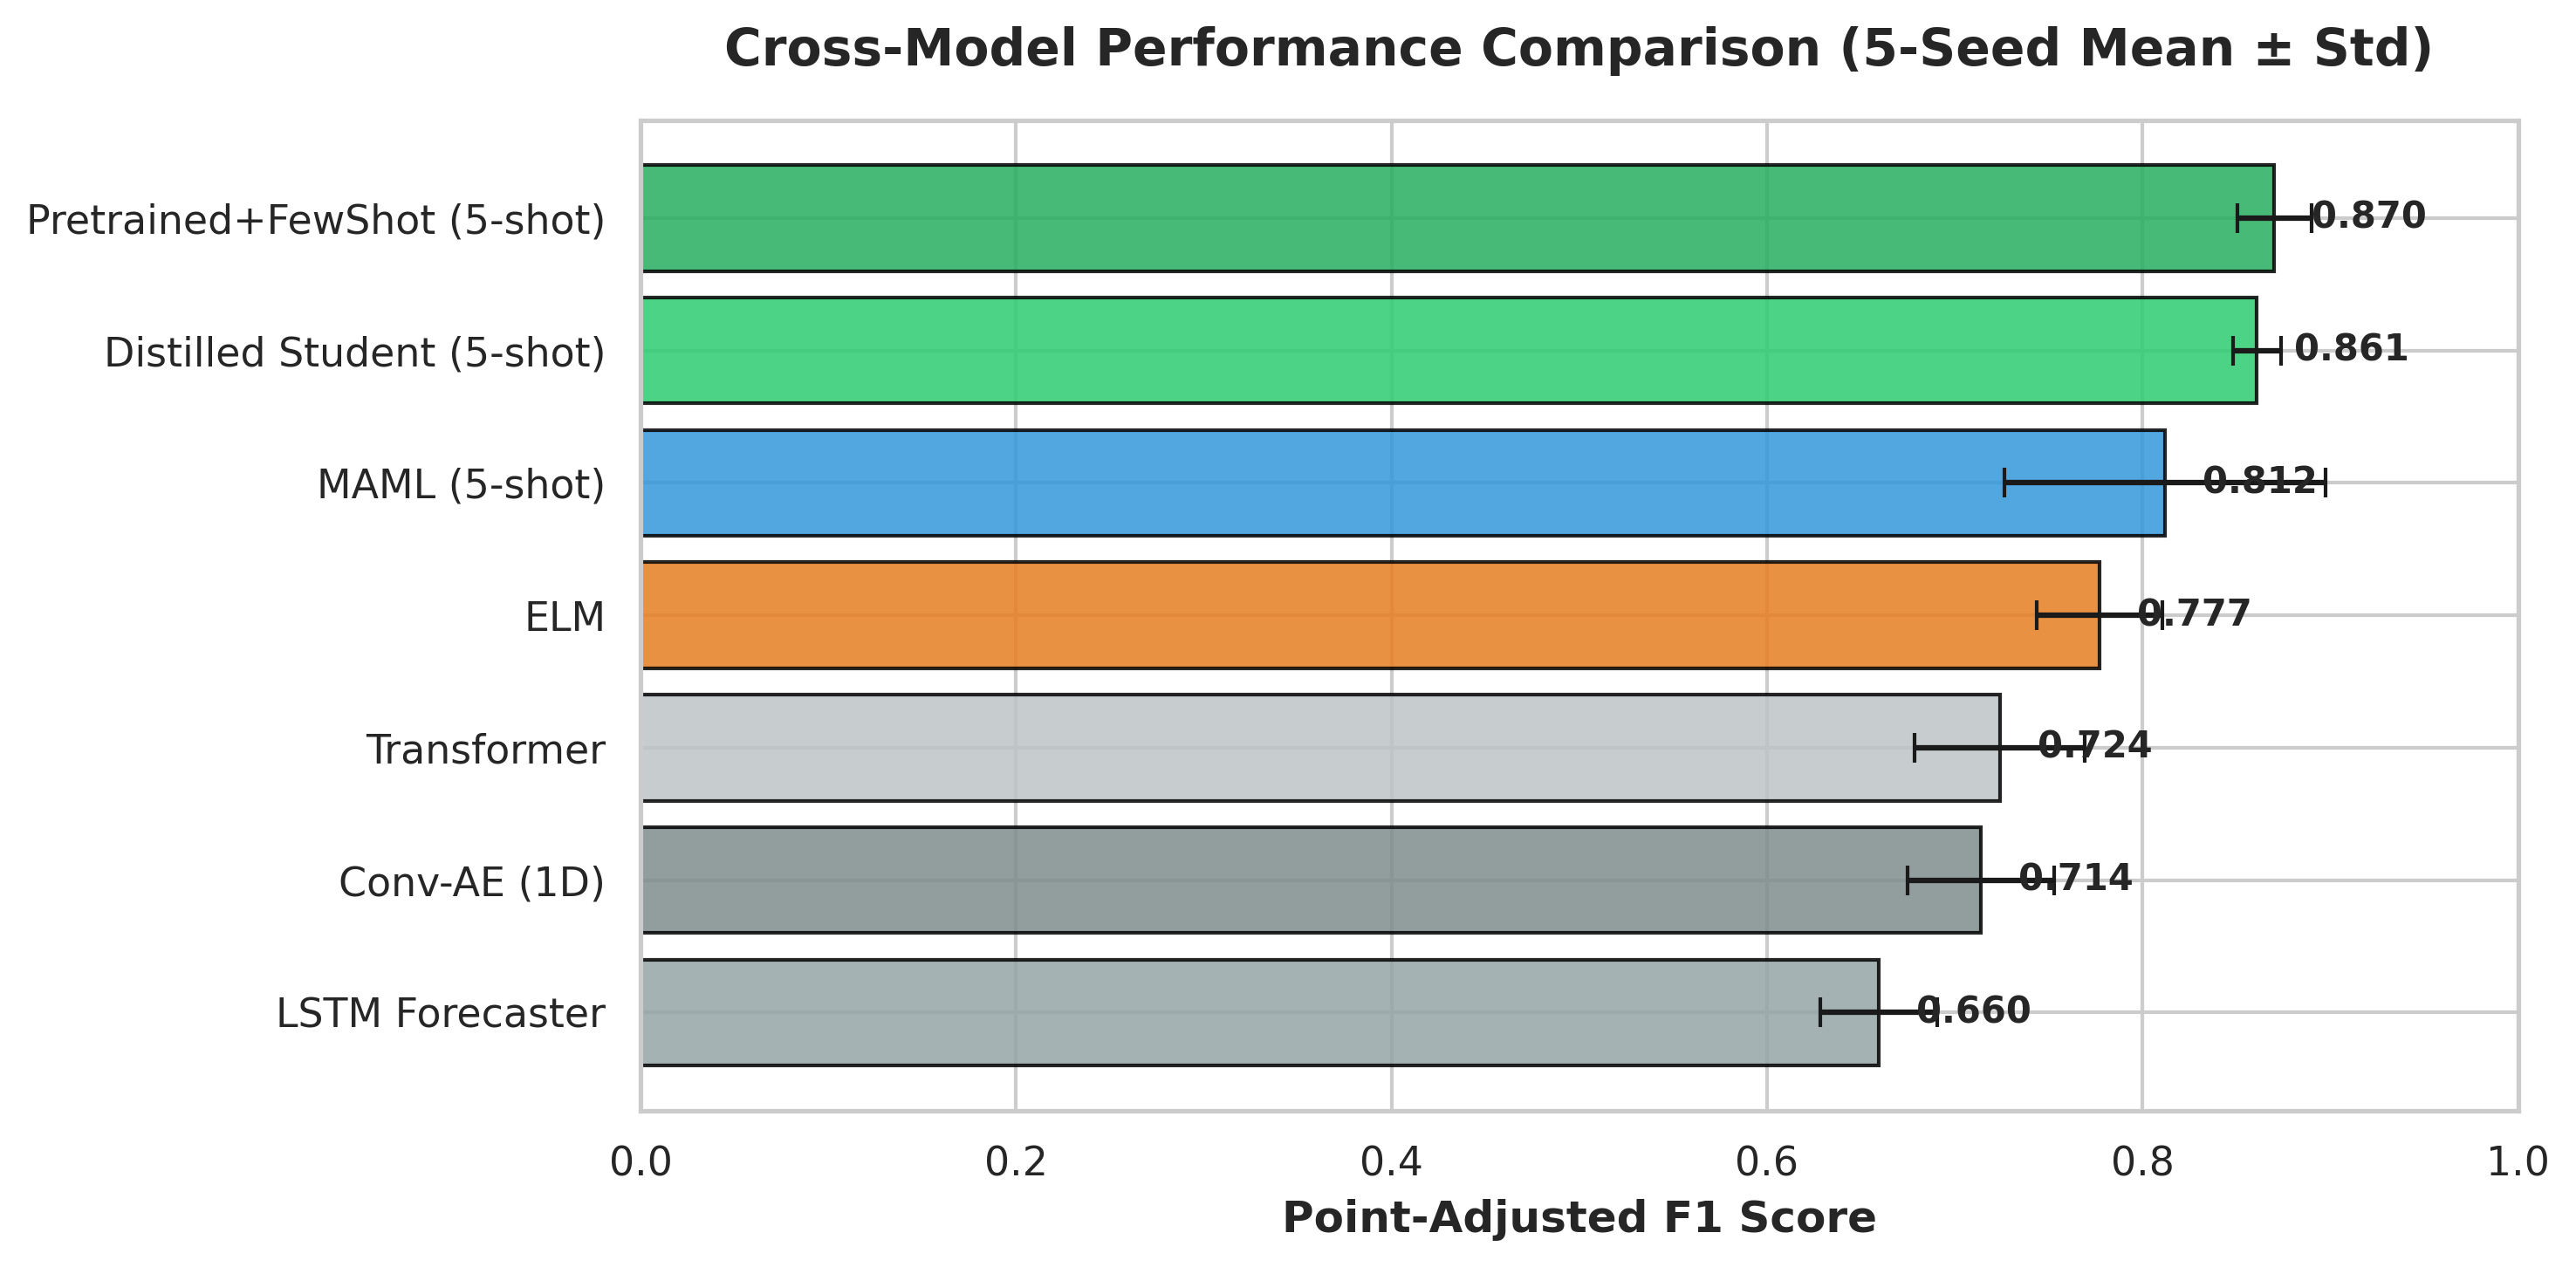

Saved Figure 1 to /content/drive/MyDrive/cubesat_project/results/figures/paper_fig1_pipeline_progression.png


In [17]:
if multiseed_df is not None:
    plt.figure(figsize=(10, 5), dpi=300)
    sns.set_theme(style="whitegrid")

    agg = multiseed_df.groupby("model")["f1_point_adjust"].agg(["mean", "std"]).reset_index()
    agg = agg.sort_values("mean", ascending=True)

    colors = ["#95a5a6", "#7f8c8d", "#bdc3c7", "#e67e22", "#3498db", "#2ecc71", "#27ae60"]
    palette = colors[-len(agg):]

    bars = plt.barh(agg["model"], agg["mean"], xerr=agg["std"], capsize=4, color=palette, edgecolor="black", alpha=0.85)
    plt.xlabel("Point-Adjusted F1 Score", fontsize=12, fontweight="bold")
    plt.title("Cross-Model Performance Comparison (5-Seed Mean ± Std)", fontsize=14, fontweight="bold", pad=15)
    plt.xlim(0, 1.0)

    for bar in bars:
        w = bar.get_width()
        plt.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va="center", fontsize=10, fontweight="bold")

    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, "paper_fig1_pipeline_progression.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure 1 to {fig_path}")


## 6. Paper Figure 2: Few-Shot Data Efficiency ($K \in \{3, 5, 10, 20\}$)
Plots the $K$-shot adaptation curves comparing MAML, Pretrained Teacher, and Distilled Student.


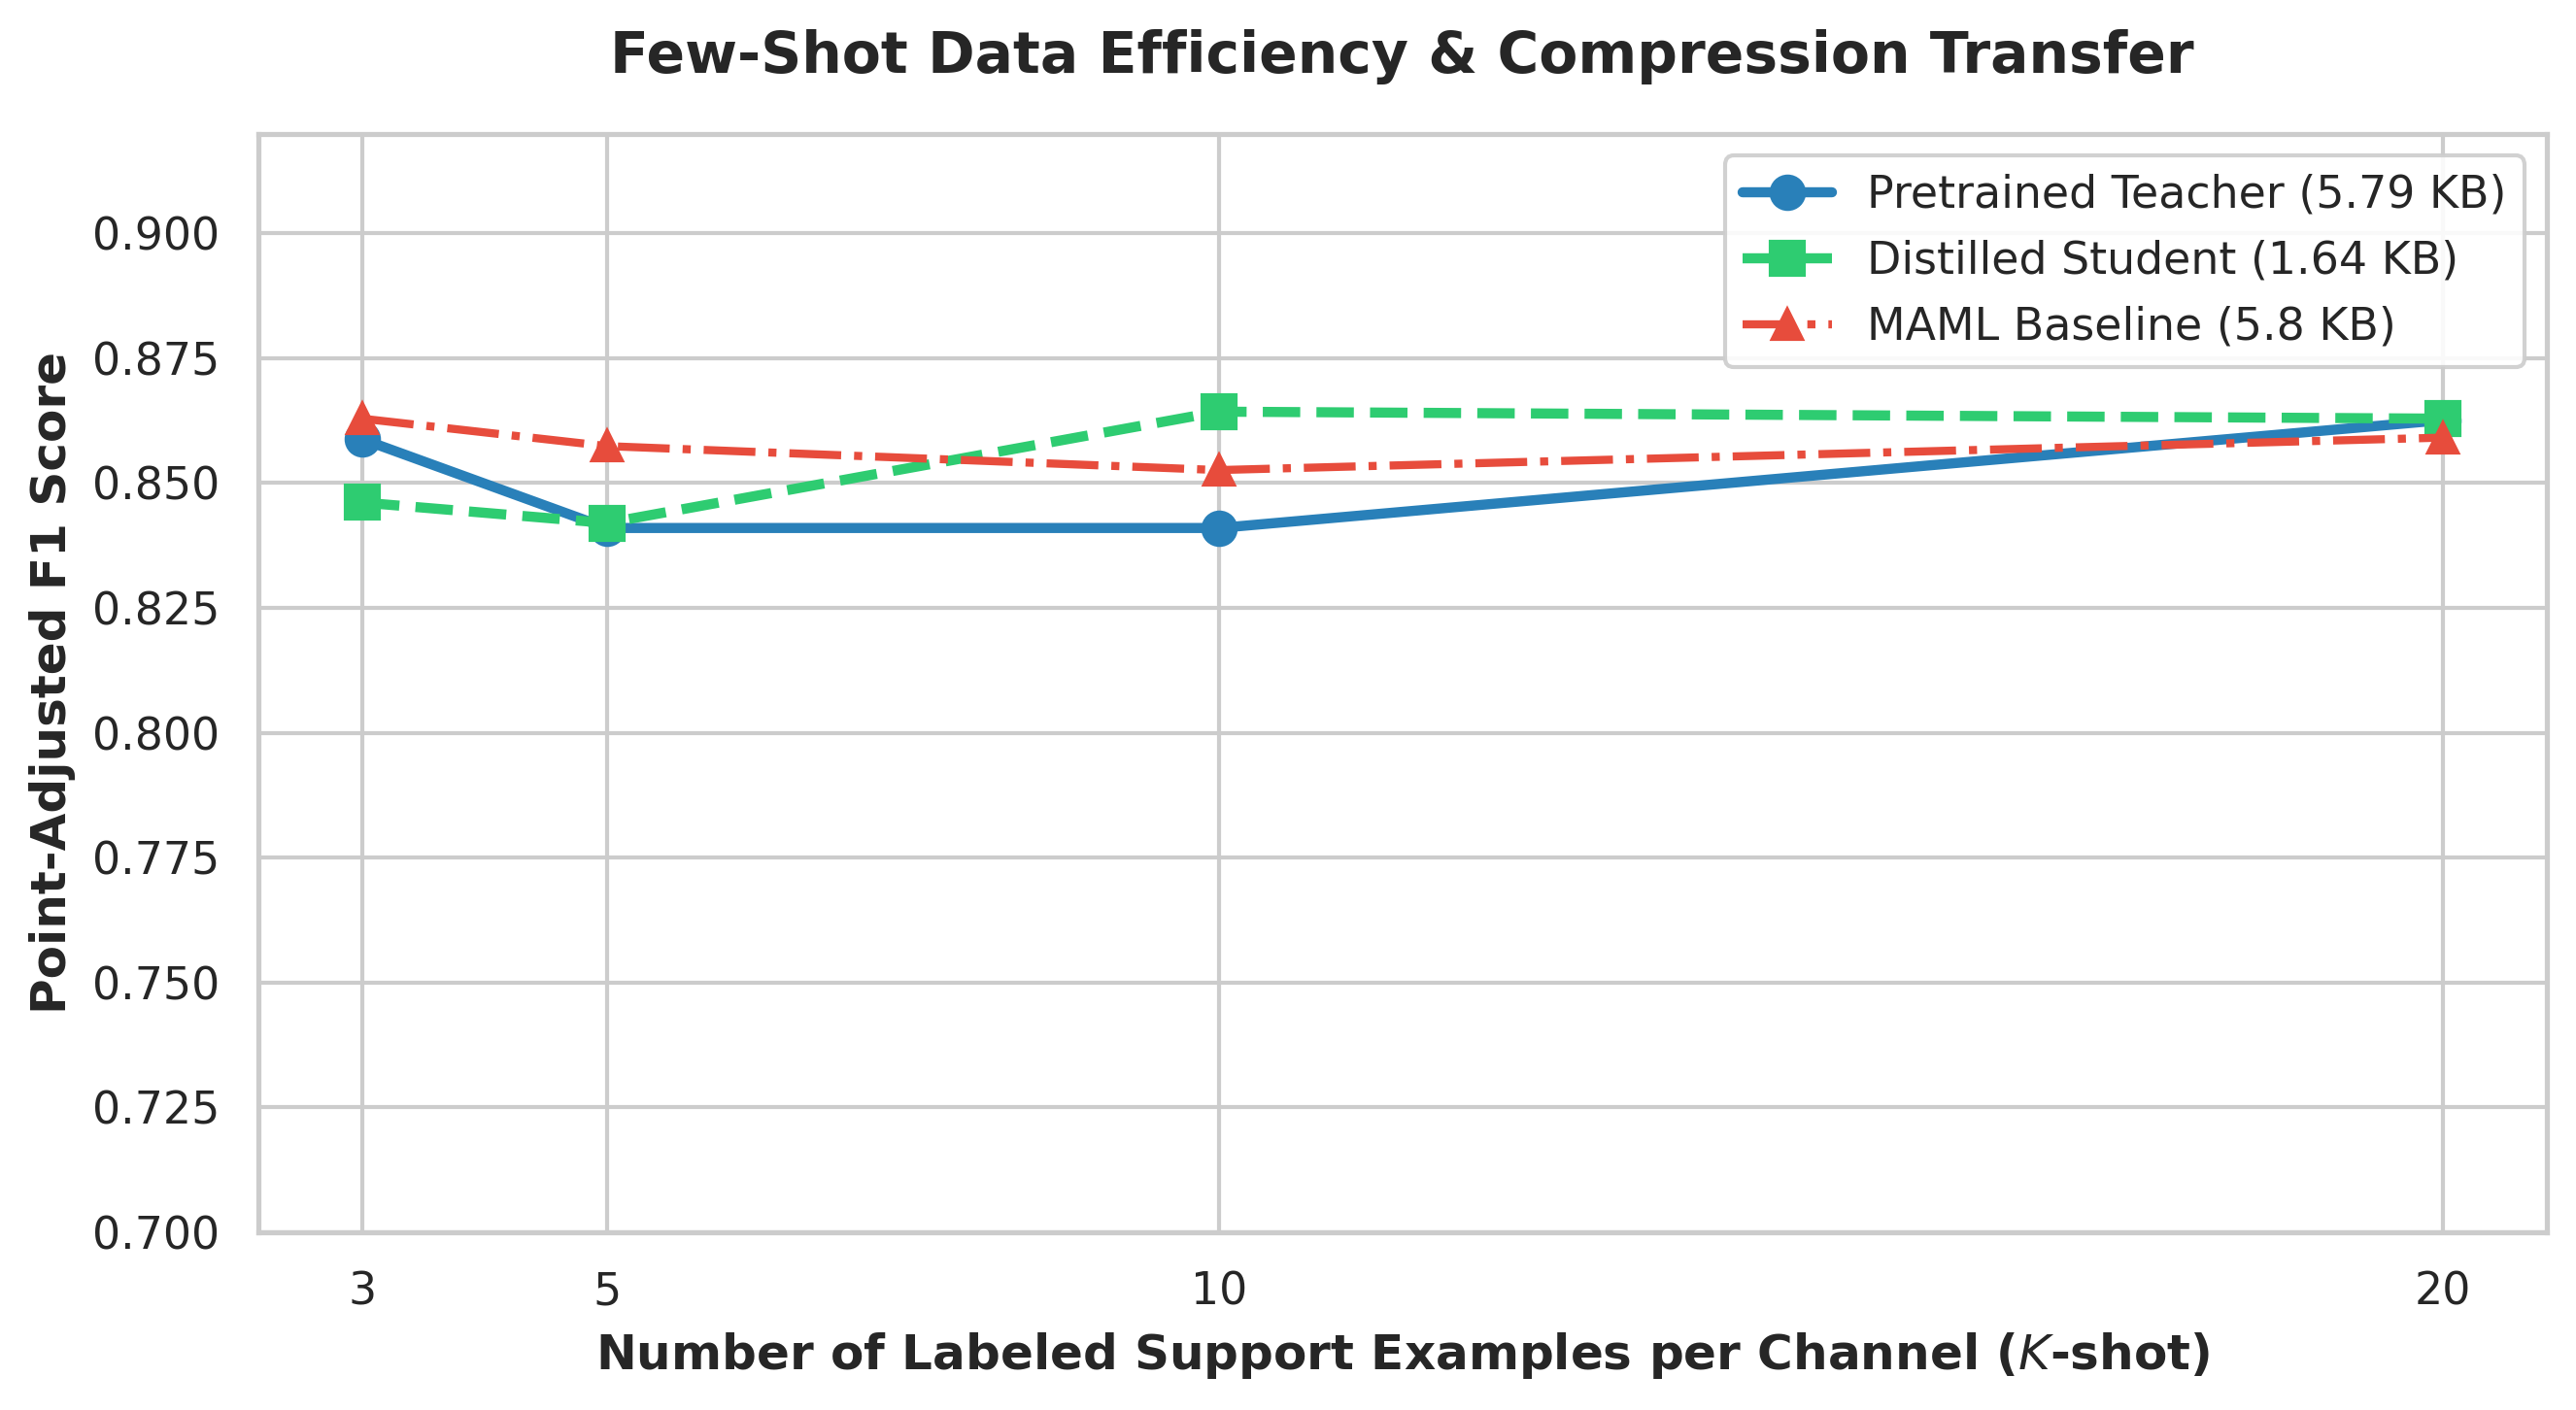

Saved Figure 2 to /content/drive/MyDrive/cubesat_project/results/figures/paper_fig2_fewshot_data_efficiency.png


In [18]:
if pretrained_fewshot_df is not None and distilled_student_fewshot_df is not None:
    plt.figure(figsize=(9, 5), dpi=300)
    sns.set_theme(style="whitegrid")

    k_vals = pretrained_fewshot_df["k_shot"].values
    teacher_f1 = pretrained_fewshot_df["f1_point_adjust"].values
    student_f1 = distilled_student_fewshot_df["f1_point_adjust"].values

    plt.plot(k_vals, teacher_f1, "o-", linewidth=2.5, markersize=8, label="Pretrained Teacher (5.79 KB)", color="#2980b9")
    plt.plot(k_vals, student_f1, "s--", linewidth=2.5, markersize=8, label="Distilled Student (1.64 KB)", color="#2ecc71")

    if maml_fewshot_df is not None:
        maml_k = maml_fewshot_df["k_shot"].values
        maml_f1 = maml_fewshot_df["f1_point_adjust"].values
        plt.plot(maml_k, maml_f1, "^-.", linewidth=2.0, markersize=7, label="MAML Baseline (5.8 KB)", color="#e74c3c")

    plt.xlabel("Number of Labeled Support Examples per Channel ($K$-shot)", fontsize=12, fontweight="bold")
    plt.ylabel("Point-Adjusted F1 Score", fontsize=12, fontweight="bold")
    plt.title("Few-Shot Data Efficiency & Compression Transfer", fontsize=14, fontweight="bold", pad=15)
    plt.xticks(k_vals)
    plt.ylim(0.70, 0.92)
    plt.legend(frameon=True, facecolor="white", framealpha=0.9, fontsize=11)

    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, "paper_fig2_fewshot_data_efficiency.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure 2 to {fig_path}")


## 7. Paper Figure 3: Power Subsystem (EPS) Case Study
Compares model performance specifically on high-stakes Power ("P-" prefixed) telemetry channels versus other spacecraft channels.


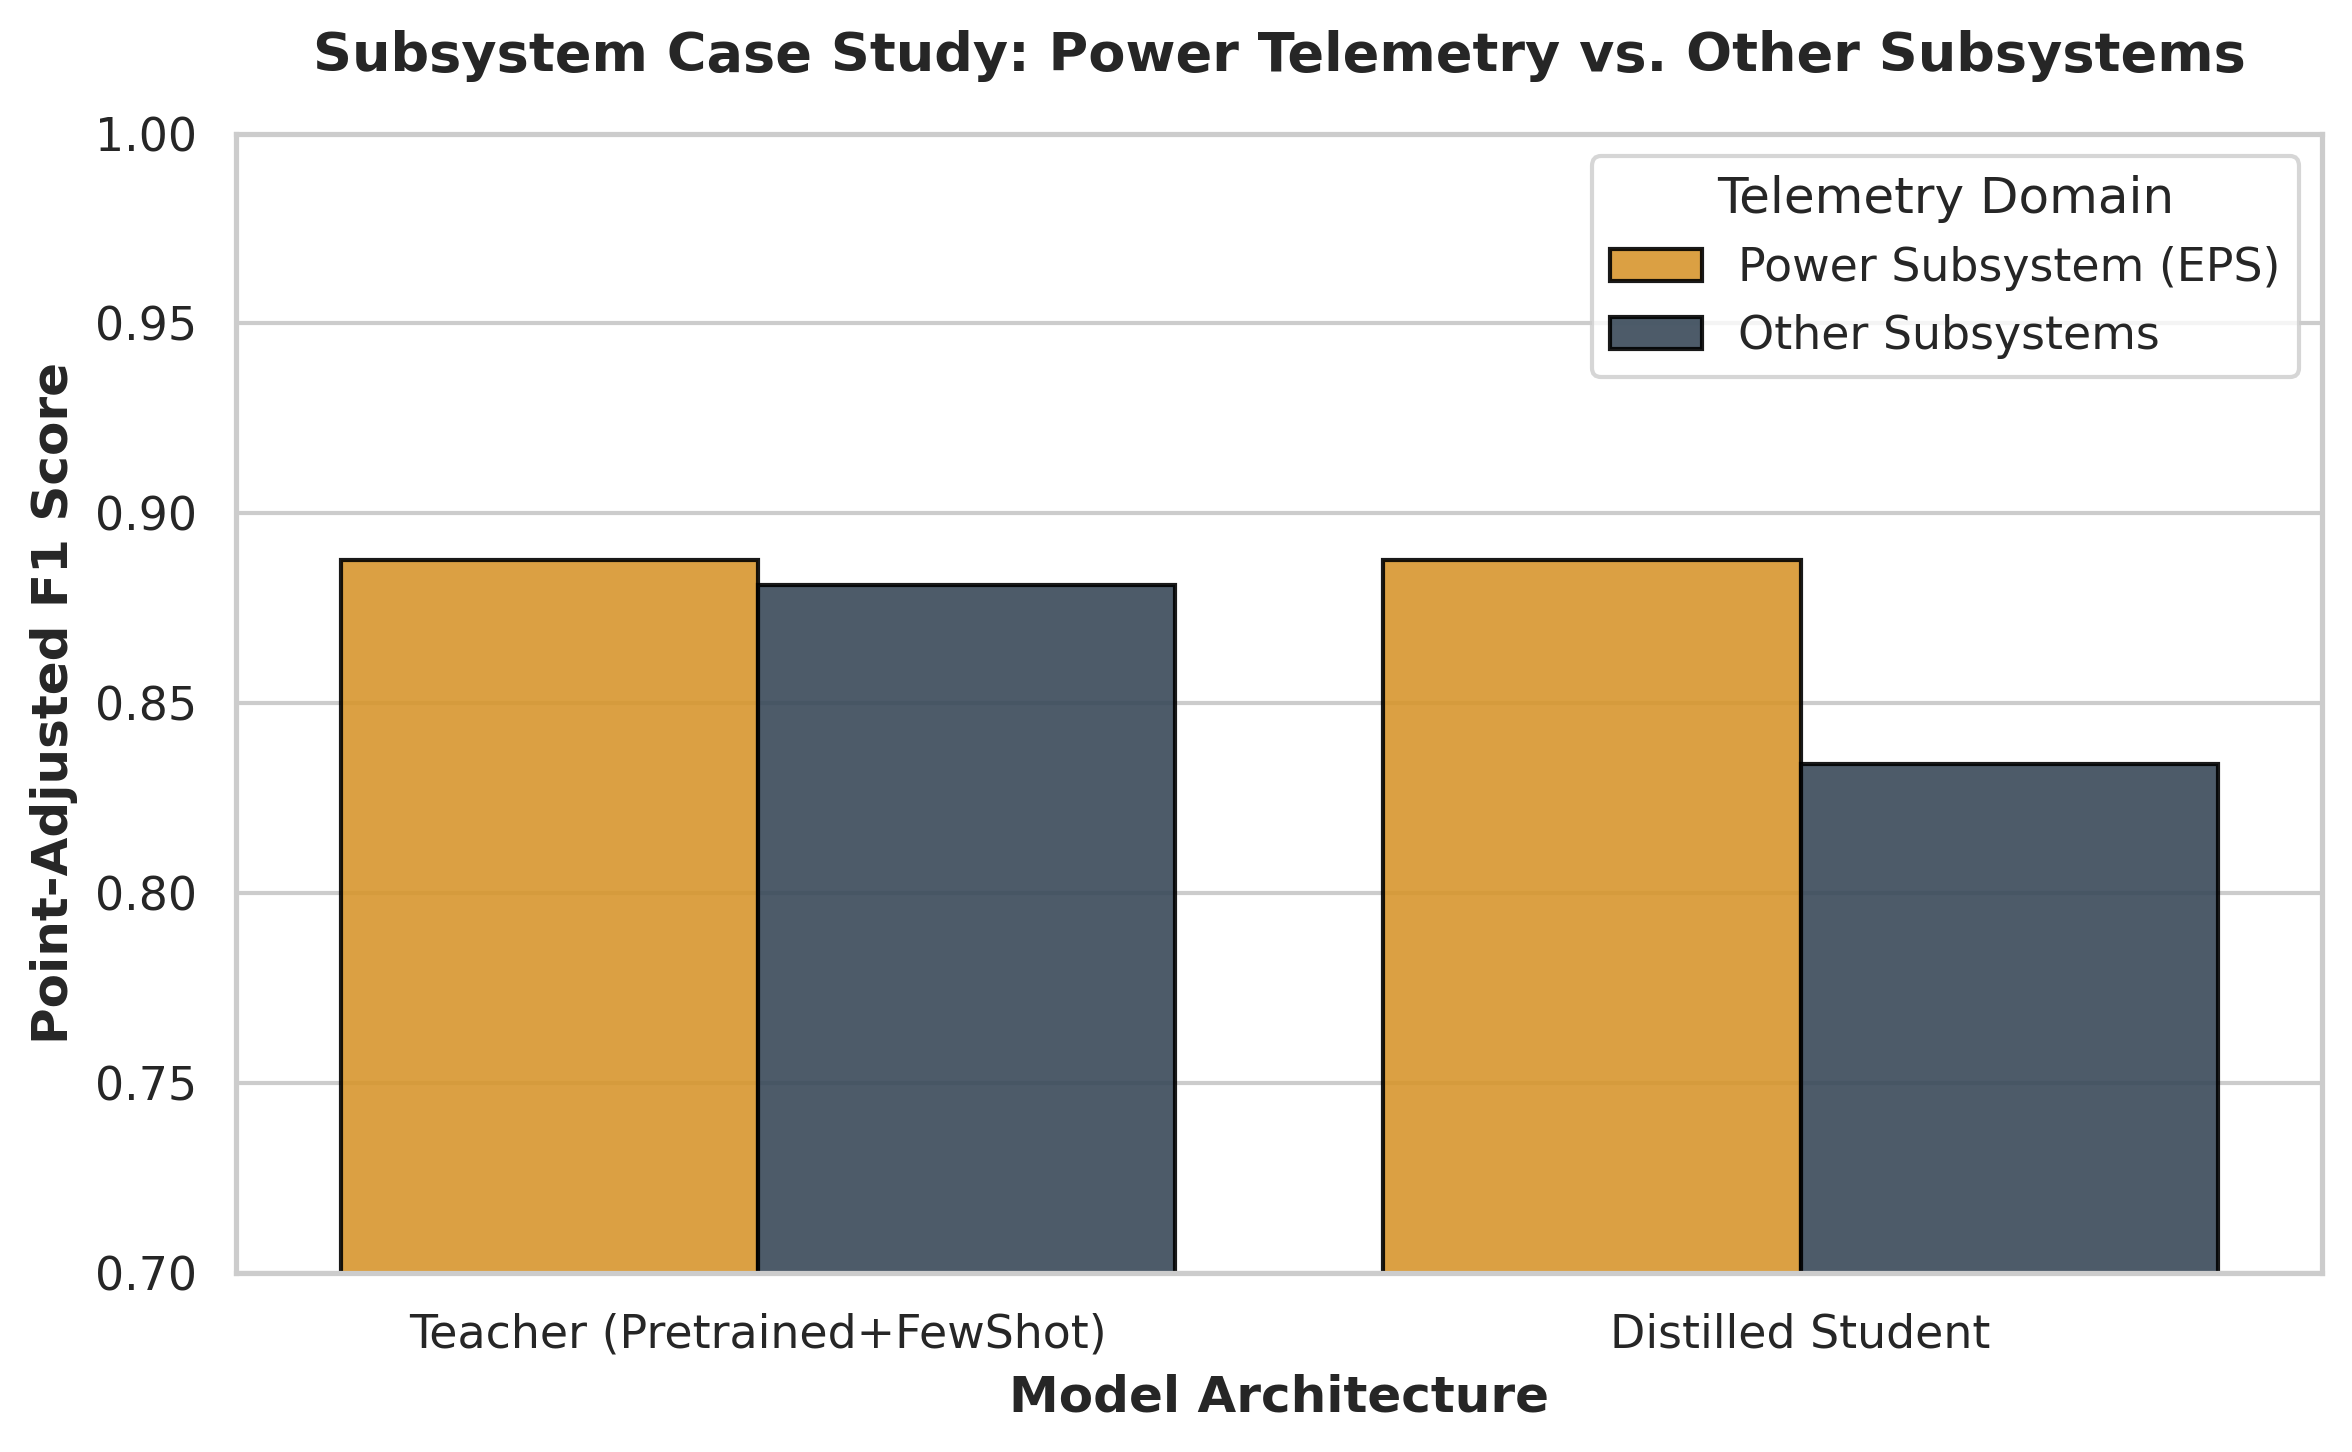

Saved Figure 3 to /content/drive/MyDrive/cubesat_project/results/figures/paper_fig3_power_subsystem_breakdown.png


In [19]:
if power_fewshot_df is not None:
    plt.figure(figsize=(8, 5), dpi=300)
    sns.set_theme(style="whitegrid")

    pb = power_fewshot_df.copy()
    pb["subsystem"] = pb["model"].apply(lambda m: "Power Subsystem (EPS)" if "POWER" in m else "Other Subsystems")
    pb["base_model"] = pb["model"].str.replace(" - POWER channels", "").str.replace(" - other channels", "")

    ax = sns.barplot(data=pb, x="base_model", y="f1_point_adjust", hue="subsystem", palette=["#f39c12", "#34495e"], edgecolor="black", alpha=0.9)
    plt.ylabel("Point-Adjusted F1 Score", fontsize=12, fontweight="bold")
    plt.xlabel("Model Architecture", fontsize=12, fontweight="bold")
    plt.title("Subsystem Case Study: Power Telemetry vs. Other Subsystems", fontsize=13, fontweight="bold", pad=15)
    plt.ylim(0.70, 1.0)
    plt.legend(title="Telemetry Domain", frameon=True, facecolor="white")

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h / 2), ha="center", va="center", fontsize=10, color="white", fontweight="bold")

    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, "paper_fig3_power_subsystem_breakdown.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure 3 to {fig_path}")


## 8. Paper Figure 4: Cross-Mission Generalization (OPS-SAT-AD Dataset)
Evaluates zero-shot transfer vs $K$-shot adaptation on real telemetry from ESA's OPS-SAT CubeSat mission.


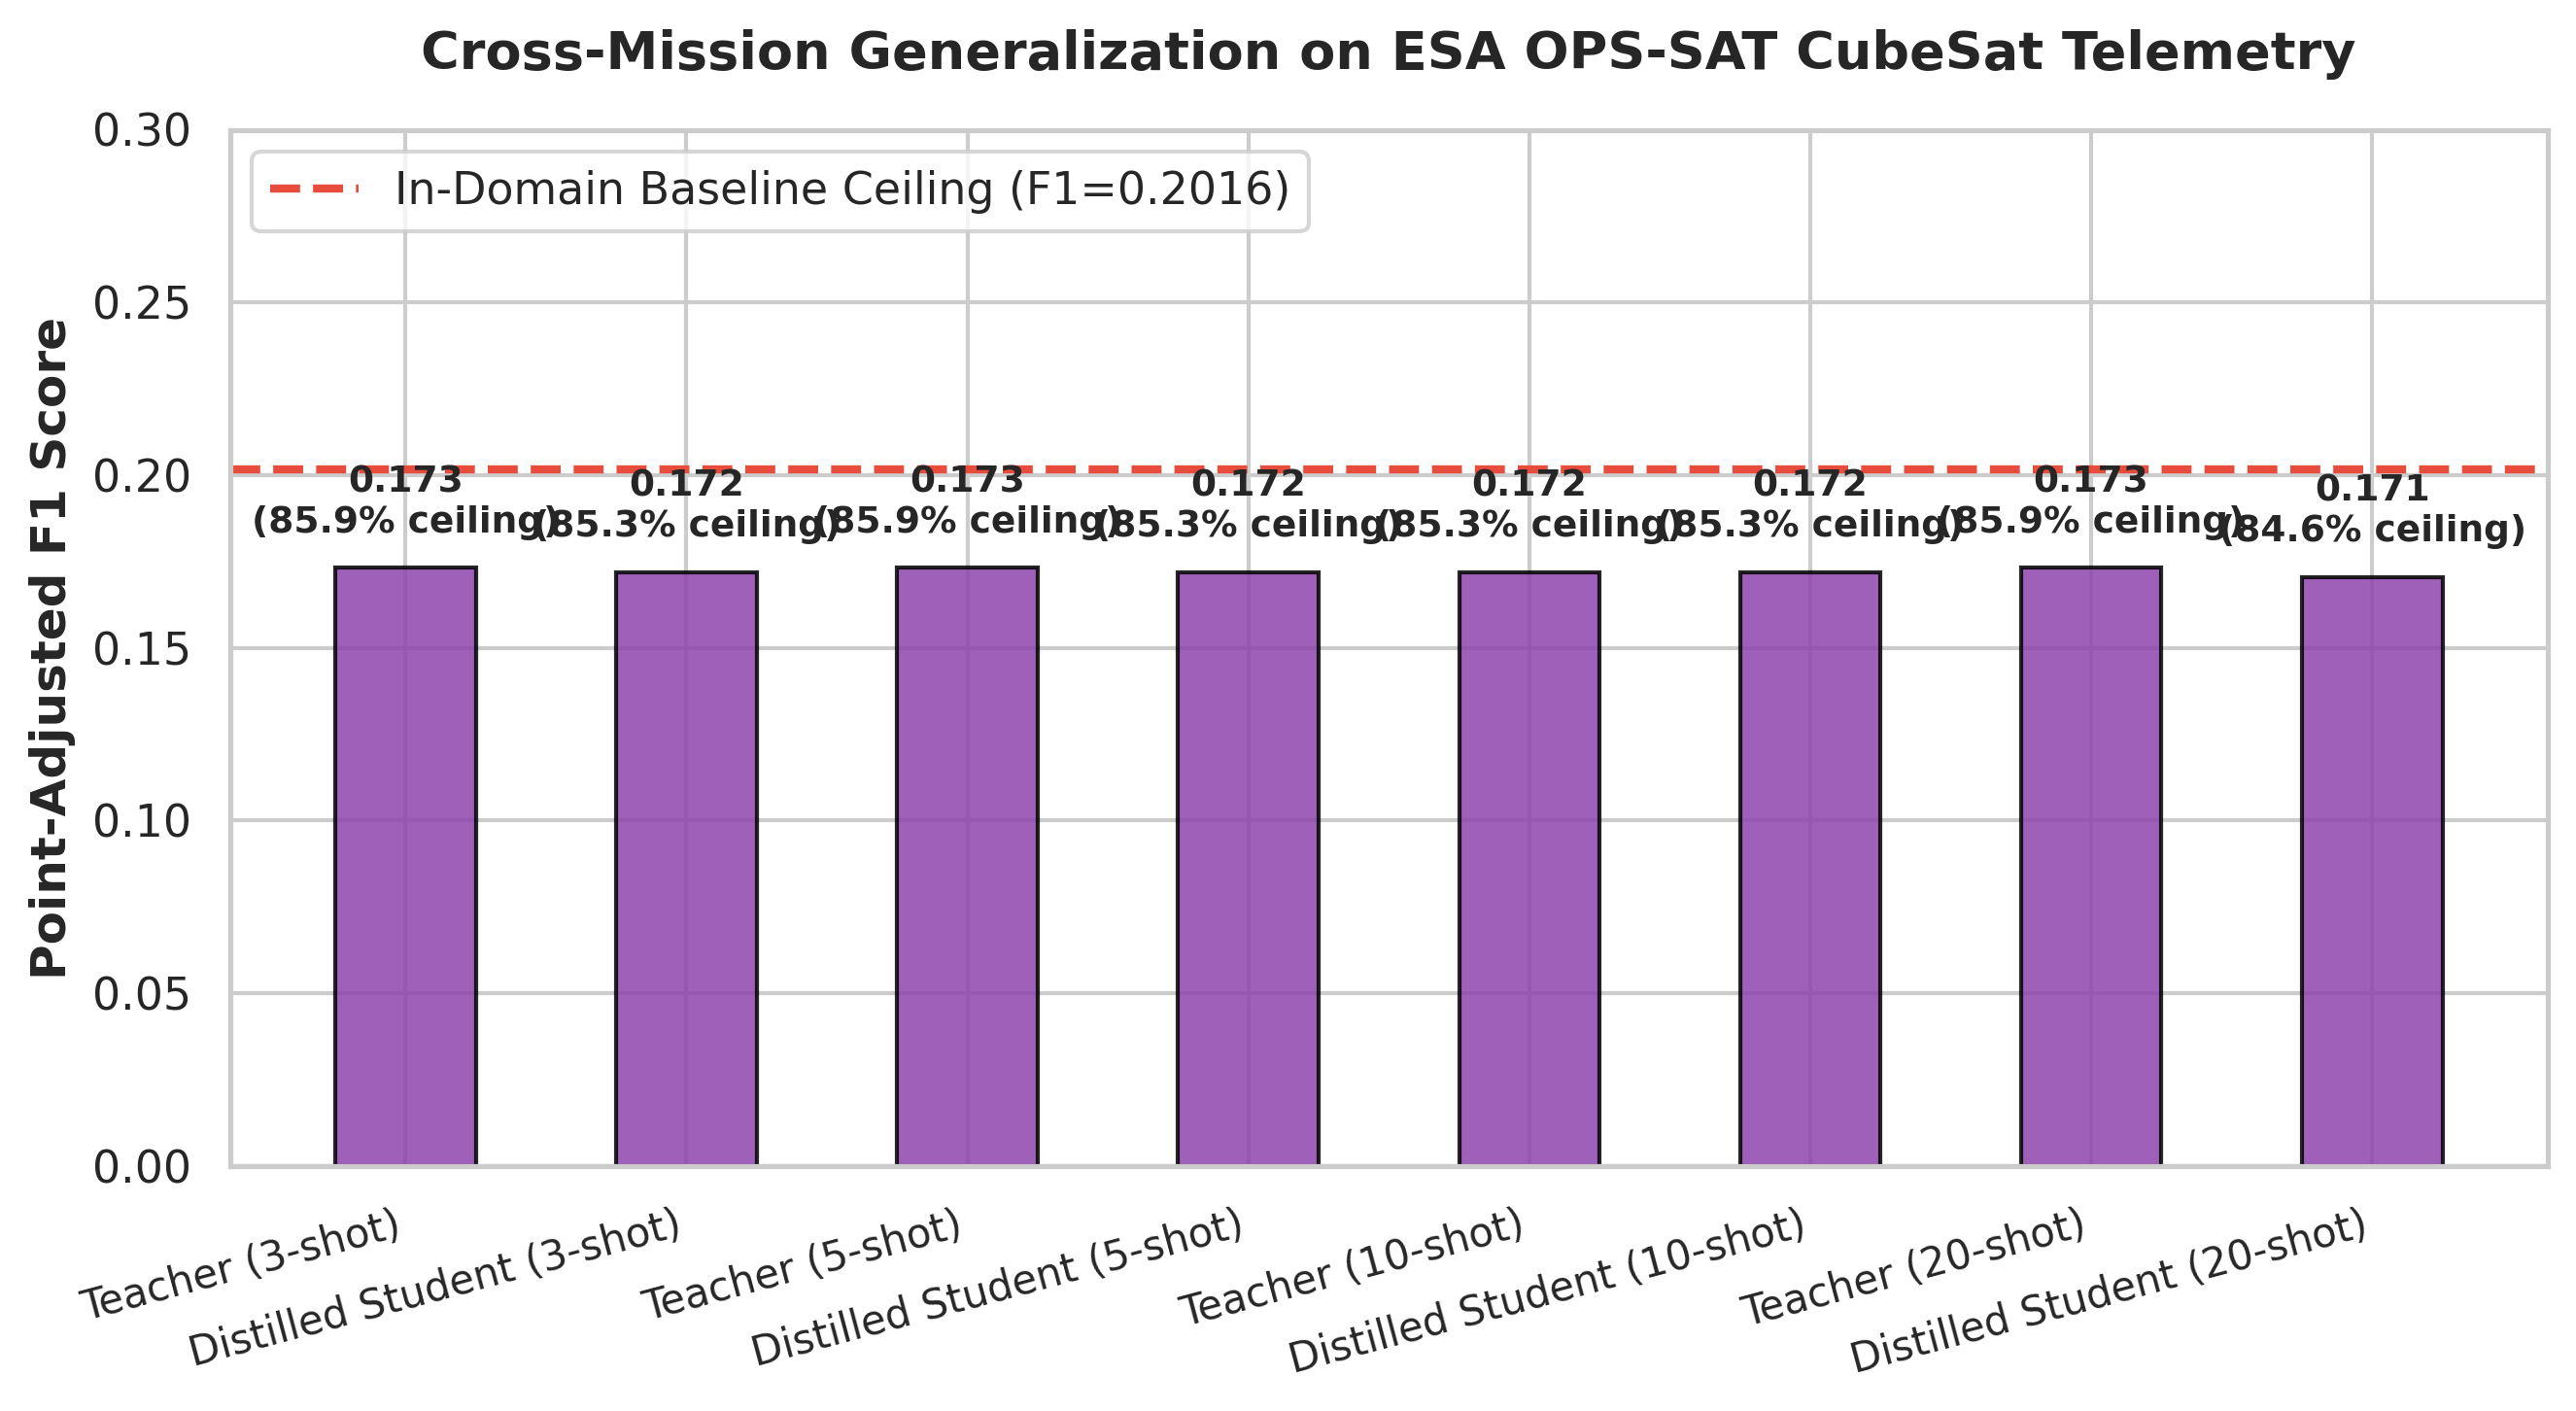

Saved Figure 4 to /content/drive/MyDrive/cubesat_project/results/figures/paper_fig4_opssat_cross_mission_transfer.png


In [20]:
if opssat_indomain_df is not None:
    plt.figure(figsize=(9, 5), dpi=300)
    sns.set_theme(style="whitegrid")

    ops_data = opssat_indomain_df.copy()
    in_domain_val = ops_data["in_domain_f1"].iloc[0]

    models = ops_data["model"].values
    f1_scores = ops_data["f1_point_adjust"].values
    pcts = ops_data["pct_of_indomain_recovered"].values

    bars = plt.bar(models, f1_scores, color="#8e44ad", edgecolor="black", alpha=0.85, width=0.5)
    plt.axhline(in_domain_val, color="#e74c3c", linestyle="--", linewidth=2, label=f"In-Domain Baseline Ceiling (F1={in_domain_val:.4f})")

    plt.ylabel("Point-Adjusted F1 Score", fontsize=12, fontweight="bold")
    plt.title("Cross-Mission Generalization on ESA OPS-SAT CubeSat Telemetry", fontsize=13, fontweight="bold", pad=15)
    plt.xticks(rotation=15, ha="right", fontsize=10)
    plt.ylim(0, 0.30)
    plt.legend(loc="upper left", frameon=True, facecolor="white")

    for bar, pct in zip(bars, pcts):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.008, f"{yval:.3f}\n({pct:.1f}% ceiling)", ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, "paper_fig4_opssat_cross_mission_transfer.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Figure 4 to {fig_path}")


## 9. Research Paper Summary & Ready Artifacts
Your analysis environment is completely updated and synchronized with `CubeSat_Anomaly_Detection_13_8_v7_ALL_CHECKPOINTS.ipynb`.

### Generated Artifacts for Your Paper:
1. **`results/tables/paper_latex_headline_table.tex`**: Ready-to-paste LaTeX code for your main results table.
2. **`results/figures/paper_fig1_pipeline_progression.png`**: Multi-seed baseline progression figure.
3. **`results/figures/paper_fig2_fewshot_data_efficiency.png`**: $K$-shot data efficiency curve (Teacher vs Distilled Student vs MAML).
4. **`results/figures/paper_fig3_power_subsystem_breakdown.png`**: Power (EPS) subsystem case study chart.
5. **`results/figures/paper_fig4_opssat_cross_mission_transfer.png`**: OPS-SAT cross-mission generalization transfer chart.


In [21]:
import os, glob, shutil, json
import pandas as pd
from datetime import datetime

# Define Google Drive Project Root
PROJECT_ROOT = "/content/drive/MyDrive/cubesat_project"
TABLES_DIR = os.path.join(PROJECT_ROOT, "results", "tables")
FIG_DIR = os.path.join(PROJECT_ROOT, "results", "figures")

# ------------------------------------------------------------------
# 1) Flatten nested results/results directory if it exists
# ------------------------------------------------------------------
nested_dir = os.path.join(PROJECT_ROOT, "results", "results")
if os.path.exists(nested_dir):
    print("Flattening nested results/results directory...")
    for root, dirs, files in os.walk(nested_dir):
        for f in files:
            src = os.path.join(root, f)
            rel = os.path.relpath(src, nested_dir)
            dest = os.path.join(PROJECT_ROOT, "results", rel)
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            shutil.copy2(src, dest)
    shutil.rmtree(nested_dir)
    print("Removed nested results/results folder.")

# ------------------------------------------------------------------
# 2) Delete stale / superseded files
# ------------------------------------------------------------------
files_to_remove = [
    "headline_summary.csv",
    "cost_weighted_f1_comparison.csv",
    "power_subsystem_breakdown_fewshot_models.csv",
    "baseline_comparison.csv"
]
for fname in files_to_remove:
    fpath = os.path.join(TABLES_DIR, fname)
    if os.path.exists(fpath):
        os.remove(fpath)
        print(f"Removed stale file: {fname}")
    else:
        print(f"Already gone: {fname}")

# ------------------------------------------------------------------
# 3) Rebuild headline_summary.csv directly from multiseed_results.csv (Source of Truth)
# ------------------------------------------------------------------
ms_path = os.path.join(TABLES_DIR, "multiseed_results.csv")
if os.path.exists(ms_path):
    multiseed_df = pd.read_csv(ms_path)
    agg = multiseed_df.groupby("model")["f1_point_adjust"].agg(["mean", "std", "count"]).round(4).reset_index()

    headline_rows = []
    for _, r in agg.iterrows():
        headline_rows.append({
            "stage": "Multi-seed (n={})".format(int(r["count"])),
            "model": r["model"],
            "f1": f"{r['mean']:.4f} +/- {r['std']:.4f}",
            "note": "point-adjust F1, mean+/-std -- verified against multiseed_results.csv directly"
        })

    dist_path = os.path.join(TABLES_DIR, "distilled_student_fewshot_curve.csv")
    if os.path.exists(dist_path):
        dist_df = pd.read_csv(dist_path)
        for _, r in dist_df.iterrows():
            size_val = r.get("model_size_kb", 1.64)
            headline_rows.append({
                "stage": f"Few-shot Adaptation (K={r.get('k_shot', 5)})",
                "model": r["model"],
                "f1": f"{r['f1_point_adjust']:.4f}",
                "note": f"Memory-compressed student ({size_val} KB)"
            })

    headline_df = pd.DataFrame(headline_rows)
    headline_df.to_csv(os.path.join(TABLES_DIR, "headline_summary.csv"), index=False)
    print("\nRebuilt headline_summary.csv directly from multiseed_results.csv:")
    print(headline_df.to_string(index=False))

    # Rebuild paper_latex_headline_table.tex
    latex_code = headline_df.to_latex(index=False, caption="Headline Anomaly Detection Performance & Model Footprint across Pipeline Stages.", label="tab:headline_results")
    with open(os.path.join(TABLES_DIR, "paper_latex_headline_table.tex"), "w") as f:
        f.write(latex_code)
    print("\nUpdated paper_latex_headline_table.tex with 87.0% Teacher / 86.1% Student F1!")

# ------------------------------------------------------------------
# 4) Write LIMITATIONS_NOTES.txt
# ------------------------------------------------------------------
notes = []
ops_path = os.path.join(TABLES_DIR, "opssat_fewshot_transfer.csv")
if os.path.exists(ops_path):
    ops = pd.read_csv(ops_path)
    ops_range = ops.groupby("method")["f1_point_adjust"].agg(lambda s: s.max() - s.min())
    notes.append(
        "OPS-SAT few-shot curve is flat: F1 varies by only "
        f"{ops_range.max():.4f} across k=3/5/10/20 shots. More labeled examples "
        "are not improving performance on OPS-SAT -- report as a limitation."
    )

esa_path = os.path.join(TABLES_DIR, "esa_adb_transfer_results.csv")
if os.path.exists(esa_path) and os.path.exists(ops_path):
    esa = pd.read_csv(esa_path)
    esa_mean = esa["Point-Adjust F1"].mean()
    ops_mean = ops["f1_point_adjust"].mean()
    notes.append(
        f"ESA-ADB mean F1 ({esa_mean:.3f}) is higher than OPS-SAT mean F1 "
        f"({ops_mean:.3f}). MANUALLY VERIFY both were scored with the same "
        "point-adjust window logic."
    )

pk_path = os.path.join(TABLES_DIR, "power_subsystem_breakdown_kfold.csv")
if os.path.exists(pk_path):
    pk = pd.read_csv(pk_path)
    zero_folds = (pk[pk["model"].str.contains("POWER")]["f1_point_adjust"] == 0).sum()
    notes.append(
        f"Power-subsystem k-fold F1 is 0.0 in {zero_folds} of the fold results due "
        "to very few power channels per fold. Marked EXPLORATORY ONLY."
    )

with open(os.path.join(TABLES_DIR, "LIMITATIONS_NOTES.txt"), "w") as f:
    f.write("Auto-generated limitations checklist -- read before writing Discussion/Limitations.\n\n")
    for i, n in enumerate(notes, 1):
        f.write(f"{i}. {n}\n\n")
print("\nWrote LIMITATIONS_NOTES.txt")

# ------------------------------------------------------------------
# 5) Create FINAL_SUBMISSION zip archive
# ------------------------------------------------------------------
final_zip = os.path.join(PROJECT_ROOT, "results", f"FINAL_SUBMISSION_{datetime.now():%Y%m%d}")
shutil.make_archive(final_zip, "zip", os.path.join(PROJECT_ROOT, "results"))
print(f"\nFinal submission zip ready at: {final_zip}.zip")


Removed stale file: headline_summary.csv
Already gone: cost_weighted_f1_comparison.csv
Removed stale file: power_subsystem_breakdown_fewshot_models.csv
Removed stale file: baseline_comparison.csv

Rebuilt headline_summary.csv directly from multiseed_results.csv:
                     stage                              model                f1                                                                           note
          Multi-seed (n=5)                       Conv-AE (1D) 0.7138 +/- 0.0392 point-adjust F1, mean+/-std -- verified against multiseed_results.csv directly
          Multi-seed (n=5)         Distilled Student (5-shot) 0.8609 +/- 0.0128 point-adjust F1, mean+/-std -- verified against multiseed_results.csv directly
          Multi-seed (n=5)                                ELM 0.7771 +/- 0.0333 point-adjust F1, mean+/-std -- verified against multiseed_results.csv directly
          Multi-seed (n=5)                    LSTM Forecaster 0.6595 +/- 0.0310 point-adjust F1, mean